# Netflix Movie Data Analysis

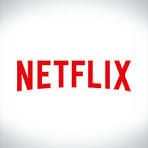

- Data scientists at Netflix play a critical role in enhancing member experience and driving business decisions through advanced analytics, machine learning. They are embedded within teams—product, content, studio, and marketing—to personalize recommendations, optimise content production/acquisition, and reduce churn.


In [1]:
# importing necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
# reading data from the source

df = pd.read_csv('.\moviedata.csv',lineterminator='\n')

# Exploratory Data Analysis

In [3]:
df.head(4)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [5]:
# first 5 gener

df['Genre'].head(5)

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

In [6]:
# Checking for duplicate records

df.duplicated().sum()

0

In [7]:
# Checking if any column contains null values

df.isnull().sum()


Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
dtype: int64

In [8]:
# stastical summerization of dataframe

df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


# Data Preprocessing

In [9]:
# droping the columns which are not required for analysis
df.drop(['Overview','Original_Language','Poster_Url'],axis=1,inplace=True)
df.head(3)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022-03-01,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022-02-25,No Exit,2618.087,122,6.3,Thriller


In [10]:
# since datatype of release_date is object we need to convert into date and time format
print(df['Release_Date'].dtypes)

object


In [11]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
print(df['Release_Date'].dtypes)

datetime64[ns]


In [12]:
# we are only dealing with years so reducing release date into years
df['Release_Date'] = df['Release_Date'].dt.year
df.head(4)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"


In [13]:
# categorising the movies based no their rating or vote_Average
def categorise_movie(df,col,labels):
    edges = [df[col].describe()['min'],
            df[col].describe()['25%'],
            df[col].describe()['50%'],
            df[col].describe()['75%'],
            df[col].describe()['max'],]
    df[col] = pd.cut(df[col], edges, labels = labels, duplicates='drop')
    return df

labels = ['Not_Popular','Below_Average','Above_Average','Popular']
df = categorise_movie(df,"Vote_Average",labels)
df.head(4)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,Popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,Below_Average,Thriller
3,2021,Encanto,2402.201,5076,Popular,"Animation, Comedy, Family, Fantasy"


In [14]:
df['Vote_Average'].unique()

['Popular', 'Below_Average', 'Above_Average', 'Not_Popular', NaN]
Categories (4, object): ['Not_Popular' < 'Below_Average' < 'Above_Average' < 'Popular']

In [16]:
# We need to drop the records having NaN value

df.isna().sum()

Release_Date      0
Title             0
Popularity        0
Vote_Count        0
Vote_Average    100
Genre             0
dtype: int64

In [17]:
# There are 100 records containing nan values

df.dropna(how = 'any', inplace = True)

In [18]:
df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

In [19]:
# finding the individual count of each category

df["Vote_Average"].value_counts()

Vote_Average
Not_Popular      2467
Popular          2450
Above_Average    2412
Below_Average    2398
Name: count, dtype: int64

<Axes: xlabel='Vote_Average', ylabel='count'>

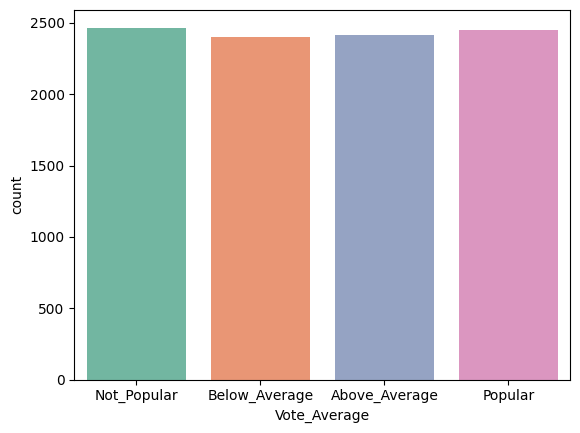

In [36]:
# visualization of individual count of each category

sns.countplot(x= df["Vote_Average"],data = df,hue = df["Vote_Average"], palette='Set2')

In [37]:
# splitting every row with respect to different genre

df['Genre'].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

In [38]:
df['Genre'] = df['Genre'].str.split(', ')
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,"[Action, Adventure, Science Fiction]"
1,2022,The Batman,3827.658,1151,Popular,"[Crime, Mystery, Thriller]"
2,2022,No Exit,2618.087,122,Below_Average,[Thriller]
3,2021,Encanto,2402.201,5076,Popular,"[Animation, Comedy, Family, Fantasy]"
4,2021,The King's Man,1895.511,1793,Above_Average,"[Action, Adventure, Thriller, War]"


In [39]:
df = df.explode('Genre').reset_index(drop=True)  # drop = True performing permanently
df.head(5)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction
3,2022,The Batman,3827.658,1151,Popular,Crime
4,2022,The Batman,3827.658,1151,Popular,Mystery


In [45]:
df.nunique()

Release_Date     100
Title           9415
Popularity      8088
Vote_Count      3265
Vote_Average       4
Genre             19
dtype: int64

In [47]:
# we need to cast the Genre to category
# Category is not a built in datatype is used to represent the categorical variable or column
df['Genre'] = df['Genre'].astype('category')

In [48]:
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

# Data Visualization

# Solving Business Questions
- What is the most frequent genre of movies released on Netflix?
- Which has highest votes in vote avg column?
- What movie got the highest popularity? what's its genre?
- What movie got the lowest popularity? what's its genre?
- Which year has the most filmmed movies?


## What is the most frequent genre of movies released on Netflix ?

In [51]:
df['Genre'].describe()

count     25552
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

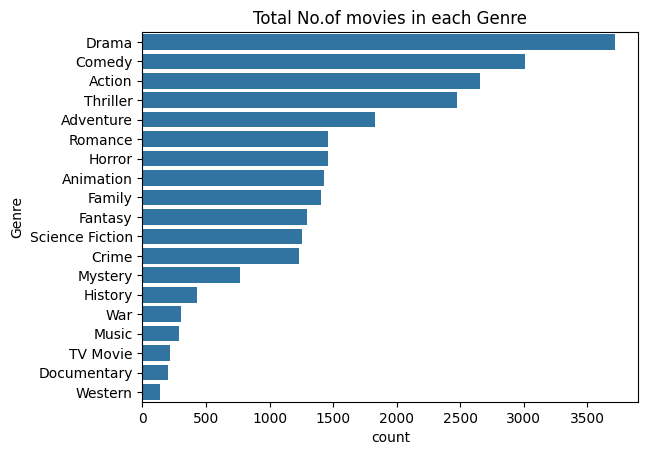

In [93]:
sns.countplot(y = "Genre", data = df, order=df['Genre'].value_counts().index)
plt.title('Total No.of movies in each Genre')
plt.show()


* Drama is the most frequent genre of movies released on Netflix.

### Which has highest votes in vote avg column?

In [86]:
df['Vote_Average'].describe()

count             25552
unique                4
top       Above_Average
freq               6613
Name: Vote_Average, dtype: object

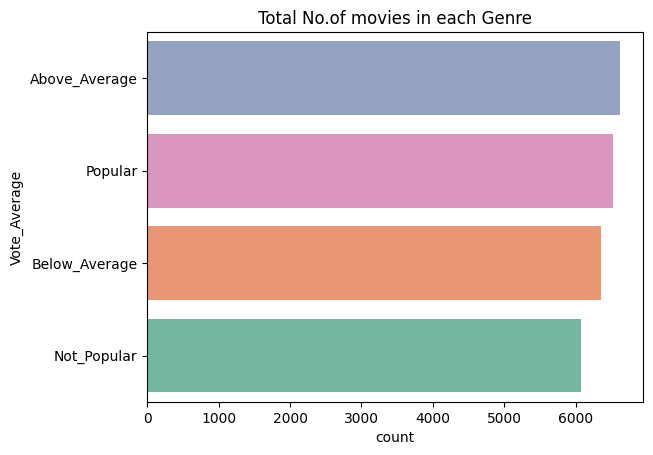

In [91]:
sns.countplot(y = "Vote_Average", data = df, order=df['Vote_Average'].value_counts().index,hue = df['Vote_Average'],palette='Set2')
plt.title('Total No.of movies in each Genre')
plt.show()

* Above_Average has highest votes in vote avg column.

### What movie got the highest popularity? what's its genre?

In [95]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction
3,2022,The Batman,3827.658,1151,Popular,Crime
4,2022,The Batman,3827.658,1151,Popular,Mystery


In [100]:
df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction


* Spider-Man: No Way Home got the highest popularity
* It's genre are [Action, Adventure, Science Fiction]

### What movie got the lowest popularity? what's its genre?

In [102]:
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25546,2021,The United States vs. Billie Holiday,13.354,152,Above_Average,Music
25547,2021,The United States vs. Billie Holiday,13.354,152,Above_Average,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152,Above_Average,History
25549,1984,Threads,13.354,186,Popular,War
25550,1984,Threads,13.354,186,Popular,Drama
25551,1984,Threads,13.354,186,Popular,Science Fiction


* The United States vs. Billie Holiday and Threads movies got lowest popularity
* The United States vs. Billie Holiday genre is [Music,Drama,History]
* Threads genre is [War,Drama,Science Fiction]

### Which year has the most filmmed movies?

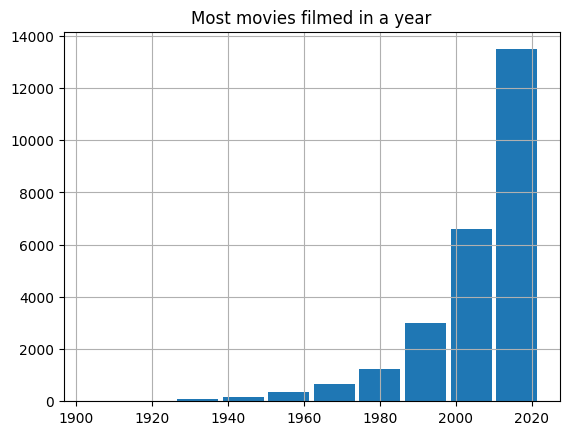

In [130]:
df['Release_Date'].hist(rwidth=0.9)
plt.title('Most movies filmed in a year')
plt.show()


* 2020 has most filmed movies